In [ ]:
import cv2
import os
from matplotlib import pyplot as plt
from google.colab import drive

import random
from PIL import Image

drive.mount('/content/drive')
pathDrive = '/content/drive/MyDrive/AWSD/VC/YOLO'
path = '/content/dataset_local'

!cp {pathDrive}/dataset.zip /content/
!unzip -q /content/dataset.zip -d /content/dataset_local

clases = ["puerta_estrella","puerta_luna","puerta_nube","puerta_sol",
        "llave_estrella","llave_luna","llave_nube","llave_sol",
        "interrogacion"]



Mounted at /content/drive


In [ ]:
!pip -q install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Training

In [ ]:
from ultralytics import YOLO

In [ ]:
model = YOLO('yolo26s.pt')
modelName = 'test_v5'
results = model.train(
    data=f'{path}/dataset/data.yaml',
    epochs=100,
    imgsz=[608, 832],
    batch=16,
    workers=2,
    device=0,
    name=modelName,
    save=True,
    amp=True
)



Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_local/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=[608, 832], int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=test_v5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

In [ ]:
modelName = 'test_v5'
!mkdir -p {pathDrive}/entrenamientos/{modelName}/
!cp -r /content/runs/detect/{modelName} {pathDrive}/entrenamientos/


# Distancias

In [ ]:
import pandas as pd

def consolidar_archivos_ordenados(ruta_dataset, total_archivos):
    lista_dataframes = []
    for i in range(total_archivos):
        archivo = os.path.join(ruta_dataset, f"distancias_objetos_{i}.txt")

        df_temporal = pd.read_csv(archivo)
        df_temporal['id_imagen'] = i

        lista_dataframes.append(df_temporal)

    df_final = pd.concat(lista_dataframes, ignore_index=True)

    columnas = ['id_imagen'] + [col for col in df_final.columns if col != 'id_imagen']
    return df_final[columnas]


In [ ]:
ruta_archivosTrain = "/content/dataset_local/dataset/train/distancias/"
ruta_archivosTest = "/content/dataset_local/dataset/test/distancias/"

total_train = 1000
total_test = 75

df_train = consolidar_archivos_ordenados(ruta_archivosTrain, total_train)
df_test = consolidar_archivos_ordenados(ruta_archivosTest, total_test)
# Mostrar el resultado final
print(df_train.head())



/tmp/ipykernel_11923/3787015757.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat(lista_dataframes, ignore_index=True)


   id_imagen  objeto  distanciaReal  x_center  y_center     width    height
0          0  puerta          1.600  0.500000  0.967693  1.000000  0.064614
1          1  puerta          1.600  0.500000  0.947065  1.000000  0.105870
2          2  puerta          1.600  0.500000  0.945140  1.000000  0.109719
3          2   llave          2.742  0.484319  0.688412  0.116053  0.190259
4          4  puerta          4.200  0.509360  0.641414  0.408978  0.178112


/tmp/ipykernel_11923/3787015757.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat(lista_dataframes, ignore_index=True)


In [ ]:
valores_unicos = df_train.groupby("objeto")["distanciaReal"].unique()
diccionario_distancias = {
    str(clase).lower(): sorted(list(valores))
    for clase, valores in df_train.groupby("objeto")["distanciaReal"].unique().items()
}

for objeto, distancias in valores_unicos.items():
    distancias.sort()
    print(f"Clase: {objeto.upper()}")
    print(f"Distancias {len(distancias)}")
    print(f"{distancias}\n")



Clase: INTERROGACION
Distancias 5
[      2.826       5.426       8.026      10.626      13.226]

Clase: LLAVE
Distancias 5
[      2.742       5.342       7.942      10.542      13.142]

Clase: PUERTA
Distancias 5
[        1.6         4.2         6.8         9.4          12]



In [ ]:
valores_unicos = df_train.groupby("objeto")["distanciaReal"].unique()

for objeto, distancias in valores_unicos.items():
    print(f"================ CLASE: {objeto.upper()} ================")

    for dist in sorted(distancias):
        df_f = df_train[(df_train["objeto"] == objeto) & (df_train["distanciaReal"] == dist)]

        print(
            f"Distancia: {dist:<6}m | "
            f"X [Dif: {df_f['x_center'].max() - df_f['x_center'].min():.3f}, Med: {df_f['x_center'].mean():.3f}] | "
            f"Y [Dif: {df_f['y_center'].max() - df_f['y_center'].min():.3f}, Med: {df_f['y_center'].mean():.3f}] | "
            f"W [Dif: {df_f['width'].max() - df_f['width'].min():.3f}, Med: {df_f['width'].mean():.3f}] | "
            f"H [Dif: {df_f['height'].max() - df_f['height'].min():.3f}, Med: {df_f['height'].mean():.3f}]"
        )

    print("\n")

================ CLASE: INTERROGACION ================
Distancia: 2.826 m | X [Dif: 0.125, Med: 0.500] | Y [Dif: 0.147, Med: 0.541] | W [Dif: 0.183, Med: 0.494] | H [Dif: 0.195, Med: 0.349]
Distancia: 5.426 m | X [Dif: 0.097, Med: 0.501] | Y [Dif: 0.094, Med: 0.393] | W [Dif: 0.098, Med: 0.268] | H [Dif: 0.101, Med: 0.197]
Distancia: 8.026 m | X [Dif: 0.075, Med: 0.501] | Y [Dif: 0.066, Med: 0.333] | W [Dif: 0.071, Med: 0.180] | H [Dif: 0.075, Med: 0.134]
Distancia: 10.626m | X [Dif: 0.070, Med: 0.501] | Y [Dif: 0.055, Med: 0.305] | W [Dif: 0.049, Med: 0.139] | H [Dif: 0.059, Med: 0.105]
Distancia: 13.226m | X [Dif: 0.069, Med: 0.497] | Y [Dif: 0.053, Med: 0.283] | W [Dif: 0.040, Med: 0.111] | H [Dif: 0.043, Med: 0.085]


================ CLASE: LLAVE ================
Distancia: 2.742 m | X [Dif: 0.078, Med: 0.500] | Y [Dif: 0.093, Med: 0.698] | W [Dif: 0.002, Med: 0.115] | H [Dif: 0.006, Med: 0.187]
Distancia: 5.342 m | X [Dif: 0.081, Med: 0.501] | Y [Dif: 0.068, Med: 0.474] | W [Dif:

In [ ]:
datos_clases = {}
for objeto, distancias in df_train.groupby("objeto")["distanciaReal"].unique().items():
    clase = objeto.lower()
    datos_clases[clase] = {}

    for dist in sorted(distancias):
        df_f = df_train[(df_train["objeto"] == objeto) & (df_train["distanciaReal"] == dist)]

        datos_clases[clase][str(dist)] = {
            "w_dif": round(df_f['width'].max() - df_f['width'].min(), 3),
            "w_med": round(df_f['width'].mean(), 3),
            "h_dif": round(df_f['height'].max() - df_f['height'].min(), 3),
            "h_med": round(df_f['height'].mean(), 3)
        }


In [ ]:
def estimar_distancia(clase, bbox):
    x, y, w, h = bbox
    margen = 0.01

    if abs(x - 0.5) > 0.15:
      #print("Desplazamiento horizontal")
      return None

    for distancia_real in reversed(list(datos_clases[clase])):
      wMed = datos_clases[clase][distancia_real]["w_med"]
      wDif = datos_clases[clase][distancia_real]["w_dif"]

      hMed = datos_clases[clase][distancia_real]["h_med"]
      hDif = datos_clases[clase][distancia_real]["h_dif"]

      if abs(w - wMed) <= ((wDif / 2)+ margen) and abs(h - hMed) <= ((hDif / 2)+ margen):
          return distancia_real

    #print("Tamaños erroneos")
    return None




# Test y avaluacion de los resultados

In [ ]:
def predictIndividual(imagenPath):
    testImg = cv2.imread(imagenPath)
    results = modelo.predict(testImg, save=False, conf=0.1)

    # Iteramos sobre los resultados
    for r in results:
      nombres_clases = r.names
      im_array = r.plot()
      im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

      plt.figure(figsize=(10, 10))
      plt.imshow(im_rgb)
      plt.axis('off')  # Oculta los ejes numéricos
      plt.show()

      for box in r.boxes:
          # Desestructuramos los 4 valores
          x_center, y_center, width, height = box.xywhn[0].tolist()

          clase_id = int(box.cls[0].item())
          nombreObj = nombres_clases[clase_id]
          nombreLimpio = nombreObj.split("_")[0]

          conf = box.conf[0].item()
          distancia = estimar_distancia(
              nombreLimpio, [x_center, y_center, width, height])

          if distancia:
            txt_dist = distancia
            celda = diccionario_distancias[nombreLimpio].index(float(distancia))
          else:
            txt_dist = "No"
            celda = "No"

          print(
              f"Objeto: {nombreObj} | Confianza: {conf:.2f} | Pos: {x_center:.2f},{y_center:.2f},{width:.2f},{height:.2f} | Distancia: {txt_dist} | Celda: {celda}"
          )

In [ ]:
modelo = YOLO(f"{pathDrive}/entrenamientos/test_v5/weights/best.pt")

In [ ]:
#Avaluar rendimiento usando test
results = modelo.val(
    data=f'dataset_local/dataset/data.yaml',
    split='test',
    imgsz=[608, 832],
    device=0
)


!cp -r /content/runs/detect/val {pathDrive}/entrenamientos/{modelName}/

WARNING ⚠️ updating to 'imgsz=832'. 'train' and 'val' imgsz must be an integer, while 'predict' and 'export' imgsz may be a [h, w] list or an integer, i.e. 'yolo export imgsz=640,480' or 'yolo export imgsz=640'
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cpu 


ValueError: Invalid CUDA 'device=0' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): False
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: None
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.


In [ ]:
#Avaluacion de las distancias


0: 640x832 1 puerta_estrella, 1591.6ms
Speed: 17.3ms preprocess, 1591.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 832)


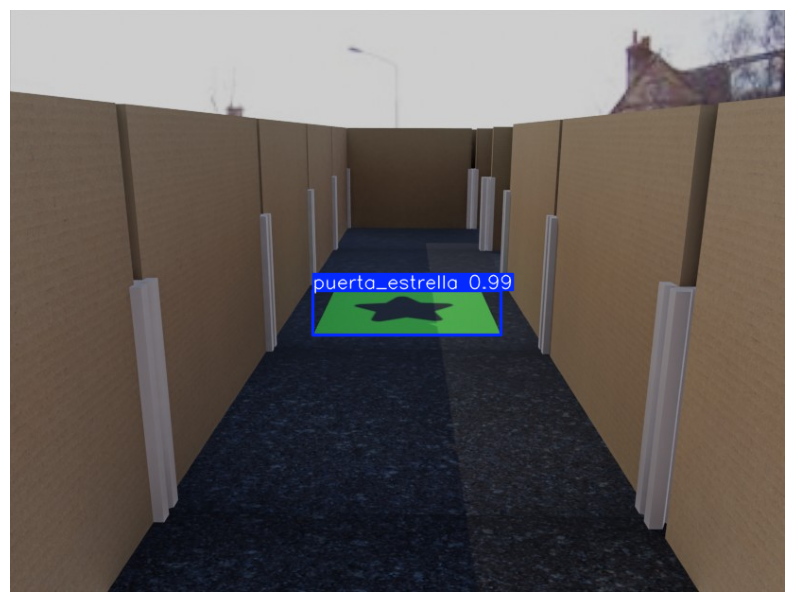

Objeto: puerta_estrella | Confianza: 0.99 | Pos: 0.51,0.52,0.24,0.08 | Distancia: 6.8 | Celda: 2


In [ ]:
#Predecir imagen individual, con distancias
predictIndividual("/content/dataset_local/dataset/test/images/img_24.jpg")

In [ ]:
total_test = 75
lista_imagenes = [
    os.path.join(path, f"dataset/test/images/img_{i}.jpg")
    for i in range(total_test)]

results = modelo.predict(lista_imagenes, save=False, conf=0.1)


0: 640x832 (no detections), 1377.1ms
1: 640x832 (no detections), 1377.1ms
2: 640x832 1 puerta_estrella, 1 interrogacion, 1377.1ms
3: 640x832 1 puerta_estrella, 1377.1ms
4: 640x832 1 puerta_nube, 1377.1ms
5: 640x832 (no detections), 1377.1ms
6: 640x832 (no detections), 1377.1ms
7: 640x832 1 puerta_estrella, 1 puerta_luna, 1 puerta_nube, 1 interrogacion, 1377.1ms
8: 640x832 (no detections), 1377.1ms
9: 640x832 (no detections), 1377.1ms
10: 640x832 1 puerta_estrella, 1 puerta_luna, 1 puerta_nube, 1377.1ms
11: 640x832 2 puerta_sols, 1377.1ms
12: 640x832 (no detections), 1377.1ms
13: 640x832 1 puerta_luna, 1377.1ms
14: 640x832 1 puerta_sol, 1377.1ms
15: 640x832 1 puerta_sol, 1 interrogacion, 1377.1ms
16: 640x832 1 puerta_estrella, 1377.1ms
17: 640x832 1 puerta_luna, 1 llave_estrella, 1377.1ms
18: 640x832 1 llave_estrella, 1377.1ms
19: 640x832 1 llave_estrella, 1377.1ms
20: 640x832 1 interrogacion, 1377.1ms
21: 640x832 1 puerta_estrella, 1 puerta_luna, 1 puerta_nube, 1377.1ms
22: 640x832 1 

In [ ]:
def evaluar_precision_distancias(df_gt, yolo_results, estimar_distancia_fn):
    predicciones = []

    # 1. Extraer predicciones válidas de forma compacta
    for i, r in enumerate(yolo_results):
        for box in r.boxes:
            obj = r.names[int(box.cls[0])].split("_")[0]
            dist = estimar_distancia_fn(obj, box.xywhn[0].tolist())

            if dist not in (None, "None"):
                try:
                    predicciones.append({'id_imagen': i, 'objeto': obj, 'distancia_estimada': round(float(dist), 3)})
                except (ValueError, TypeError): pass

    if not predicciones: return "No hay predicciones válidas numéricas para evaluar."

    df_gt['distanciaReal'] = pd.to_numeric(df_gt['distanciaReal'], errors='coerce').round(3)
    df_match = pd.merge(df_gt[['id_imagen', 'objeto', 'distanciaReal']], pd.DataFrame(predicciones), on=['id_imagen', 'objeto'])

    df_match['ok'] = df_match['distanciaReal'] == df_match['distancia_estimada']

    reporte = df_match.groupby('objeto')['ok'].agg(
        Distancia_CORRECTA='sum',
        Distancia_INCORRECTA=lambda x: (~x).sum()
    )

    reporte['%_Exito_Medicion'] = (reporte['Distancia_CORRECTA'] / (reporte['Distancia_CORRECTA'] + reporte['Distancia_INCORRECTA']) * 100).round(2)
    return reporte

In [ ]:
def obtener_imagenes_con_fallos(df_gt, yolo_results, estimar_distancia_fn):
    predicciones = []

    for i, r in enumerate(yolo_results):
        for box in r.boxes:
            cls_id = int(box.cls[0])
            nombre_objeto = r.names[cls_id]
            nombre_objeto = nombre_objeto.split("_")[0]

            bbox_normalizado = box.xywhn[0].tolist()
            dist_estimada = estimar_distancia_fn(nombre_objeto, bbox_normalizado)

            if dist_estimada is None or dist_estimada == "None":
                continue

            try:
                dist_num = round(float(dist_estimada), 3)
            except (ValueError, TypeError):
                continue

            predicciones.append({
                'id_imagen': i,
                'objeto': nombre_objeto,
                'distancia_estimada': dist_num
            })

    df_pred = pd.DataFrame(predicciones)
    if df_pred.empty:
        return pd.DataFrame(columns=['id_imagen', 'objeto', 'distanciaReal', 'distancia_estimada', 'tipo_error'])

    df_gt_copy = df_gt.copy()
    df_gt_copy['distanciaReal'] = pd.to_numeric(df_gt_copy['distanciaReal'], errors='coerce').round(3)

    df_match = pd.merge(
        df_gt_copy[['id_imagen', 'objeto', 'distanciaReal']],
        df_pred,
        on=['id_imagen', 'objeto'],
        how='inner'
    )

    df_match['distancia_correcta'] = df_match['distanciaReal'] == df_match['distancia_estimada']

    df_fallos = df_match[df_match['distancia_correcta'] == False].copy()
    df_fallos['tipo_error'] = 'Error de Cálculo de Distancia'
    df_fallos = df_fallos.drop(columns=['distancia_correcta'])

    return df_fallos.sort_values(by='id_imagen').reset_index(drop=True)

In [ ]:
#Porcentajes
df_porcentajes = evaluar_precision_distancias(df_test, results, estimar_distancia)
print("--- PORCENTAJES DE ÉXITO ---")
print(df_porcentajes)

print("\n--------------------------------------------------\n")

#Errores
df_lista_errores = obtener_imagenes_con_fallos(df_test, results, estimar_distancia)
print("--- DETALLE DE IMÁGENES CON ERROR ---")
print(df_lista_errores.head(20))

--- PORCENTAJES DE ÉXITO ---
               Distancia_CORRECTA  Distancia_INCORRECTA  %_Exito_Medicion
objeto                                                                   
interrogacion                  18                     0             100.0
llave                          17                     3              85.0
puerta                         35                     0             100.0

--------------------------------------------------

--- DETALLE DE IMÁGENES CON ERROR ---
   id_imagen objeto  distanciaReal  distancia_estimada  \
0         22  llave         10.542              13.142   
1         52  llave         10.542              13.142   
2         66  llave         10.542              13.142   

                      tipo_error  
0  Error de Cálculo de Distancia  
1  Error de Cálculo de Distancia  
2  Error de Cálculo de Distancia  
